# Calefacción Inteligente
Se entrenará un agente mediante aprendizaje por refuerzo en un entorno personalizado, donde deberá mantener la temperatura de una habitación lo más cercana posible a un valor objetivo, utilizando la menor cantidad de energía.

El agente podrá encender o apagar la calefacción, observando la temperatura actual, la temperatura exterior y la deseada.
Las recompensas se diseñarán en función de dos factores principales:

## Confort térmico:
Penalizando la desviación entre la temperatura actual y la temperatura objetivo, si el agente puede llegar a una temperatura objetivo cercana o igual se lo recompensará.

## Eficiencia energética:
Penalizando el uso excesivo de la calefacción, solo se debe enviar la cantidad suficiente de calor o de frio para alcanzar la temperatura deseada, sin gastar energia de mas.

De esta forma, el agente aprenderá una política óptima que equilibre el confort y el ahorro energético, simulando el comportamiento de un sistema inteligente de climatización doméstico.

## Definición de variables y entrenamiento:

In [83]:
import numpy as np
import pickle
import random

# ======================================
# PARÁMETROS DEL ENTRENAMIENTO
# ======================================
max_episodes = 50000
max_steps = 500

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.00002
epsilon_min = 0.05

T_margin = 1.0            # margen donde consideramos que está "bien"
C = 8.0                   # capacidad térmica
R = 10.0                  # resistencia térmica
dt = 5.0                  # paso de simulación
max_heat_step = 10.0      # calor/frío máximo que puede aplicar la acción

# ======================================
# DISCRETIZACIÓN
# ======================================
T_in_bins  = np.linspace(-20, 40, 30)
T_out_bins = np.linspace(-20, 40, 30)
T_set_bins = np.linspace(-10, 40, 11)

actions = [0, 1]  # 0 = no prender calefaccion, 1 = actuar aplicando calor o frío

# Q-table inicial
q_table = np.zeros((len(T_in_bins)+1,
                    len(T_out_bins)+1,
                    len(T_set_bins)+1,
                    len(actions)))

rng = np.random.default_rng()

# ======================================
# FUNCIÓN DE RECOMPENSA
# ======================================
def compute_reward(T_in, T_set, heat_power):
    error = abs(T_in - T_set)

    # si está dentro de 1 grado cerca al objetivo → excelente
    if error <= T_margin:
        return 200 - 0.1 * abs(heat_power)

    # si está lejos → castigo fuerte
    return -10 * error - 0.1 * abs(heat_power)

# ======================================
# ENTRENAMIENTO
# ======================================
rewards_per_episode = []

for episode in range(max_episodes):

    T_in  = rng.uniform(0, 25)
    T_out = rng.uniform(-10, 36)
    T_set = rng.uniform(15, 25)

    total_reward = 0

    for step in range(max_steps):

        state_in  = np.digitize(T_in, T_in_bins)
        state_out = np.digitize(T_out, T_out_bins)
        state_set = np.digitize(T_set, T_set_bins)

        # Política ε-greedy
        if rng.random() < epsilon:
            action = rng.choice(actions)
        else:
            action = np.argmax(q_table[state_in, state_out, state_set, :])

        heat_loss = (T_out - T_in) / R

        if action == 1:
            heat_power = np.clip(T_set - T_in, -max_heat_step, max_heat_step)
        else:
            heat_power = 0.0

        T_in_new = T_in + (dt / C) * (heat_loss + heat_power)

        reward = compute_reward(T_in_new, T_set, heat_power)
        total_reward += reward

        new_state_in  = np.digitize(T_in_new, T_in_bins)
        new_state_out = np.digitize(T_out, T_out_bins)

        q_table[state_in, state_out, state_set, action] += alpha * (
            reward + gamma * np.max(q_table[new_state_in, new_state_out, state_set, :])
            - q_table[state_in, state_out, state_set, action]
        )

        T_in = T_in_new

    rewards_per_episode.append(total_reward)

    epsilon = max(epsilon - epsilon_decay, epsilon_min)

    if episode % 500 == 0:
        mean_r = np.mean(rewards_per_episode[-500:])
        print(f"Episodio: {episode}, Recompensa media últimos 500: {mean_r:.2f}, Epsilon: {epsilon:.3f}")

# ======================================
# GUARDAR Q-TABLE
# ======================================
with open("calefaccion_q_table.pkl", "wb") as f:
    pickle.dump(q_table, f)

print("Entrenamiento completado")
print("Q-table guardada como 'calefaccion_q_table.pkl'")


Episodio: 0, Recompensa media últimos 500: -14631.55, Epsilon: 1.000
Episodio: 500, Recompensa media últimos 500: 17997.19, Epsilon: 0.990
Episodio: 1000, Recompensa media últimos 500: 18242.46, Epsilon: 0.980
Episodio: 1500, Recompensa media últimos 500: 17382.58, Epsilon: 0.970
Episodio: 2000, Recompensa media últimos 500: 17297.18, Epsilon: 0.960
Episodio: 2500, Recompensa media últimos 500: 24688.13, Epsilon: 0.950
Episodio: 3000, Recompensa media últimos 500: 20483.98, Epsilon: 0.940
Episodio: 3500, Recompensa media últimos 500: 17557.99, Epsilon: 0.930
Episodio: 4000, Recompensa media últimos 500: 23576.13, Epsilon: 0.920
Episodio: 4500, Recompensa media últimos 500: 23591.21, Epsilon: 0.910
Episodio: 5000, Recompensa media últimos 500: 20335.96, Epsilon: 0.900
Episodio: 5500, Recompensa media últimos 500: 21291.04, Epsilon: 0.890
Episodio: 6000, Recompensa media últimos 500: 21417.29, Epsilon: 0.880
Episodio: 6500, Recompensa media últimos 500: 21073.38, Epsilon: 0.870
Episodio:

## Gráfica de entrenamiento:

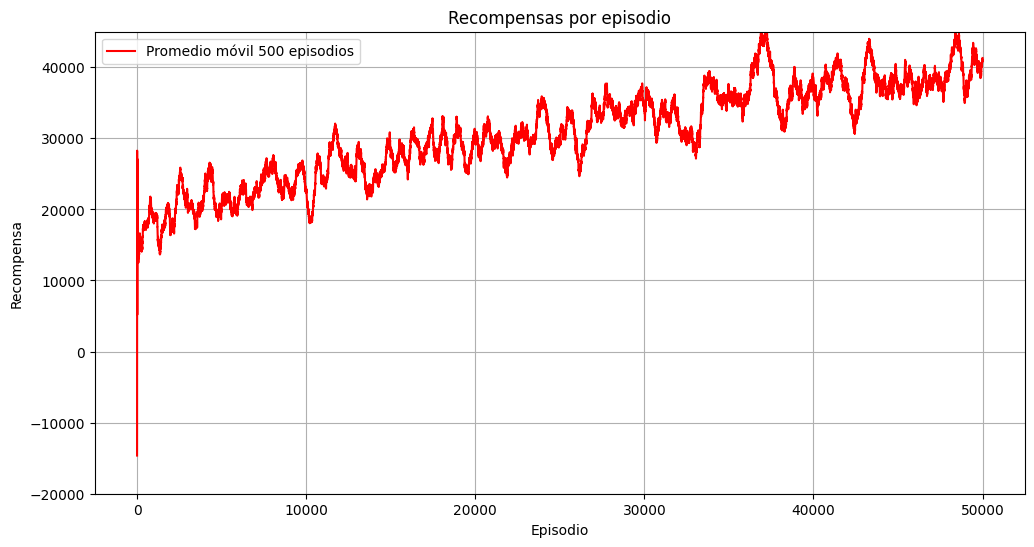

In [98]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

window = 500
moving_avg = [np.mean(rewards_per_episode[i-window:i]) if i>=window else np.mean(rewards_per_episode[:i+1]) 
              for i in range(len(rewards_per_episode))]
plt.plot(moving_avg, label=f"Promedio móvil {window} episodios", color='red')

plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Recompensas por episodio")
plt.legend()
plt.grid(True)
plt.ylim(-20000, 45000)

plt.show()



## Simulación en PyGame utilizando el agente entrenado:

In [99]:
import pygame
import pickle
import numpy as np

with open('calefaccion_q_table.pkl', 'rb') as f:
    q_table = pickle.load(f)

pygame.init()
screen = pygame.display.set_mode((600, 450))
pygame.display.set_caption("Calefacción Inteligente")
font = pygame.font.SysFont("Arial", 20)
clock = pygame.time.Clock()

house_sprite = pygame.image.load("casa.png").convert_alpha()
house_sprite = pygame.transform.scale(house_sprite, (300, 300))

# Variables del sistema térmico
T_in = 15.0
display_T_in = T_in
T_out = 0.0
T_set = 21.0

C = 8.0
R = 10.0
dt = 5.0
max_heat_step = 10.0
T_margin = 1.0

running = True

# Discretización
T_in_bins  = np.linspace(-20, 40, 30)
T_out_bins = np.linspace(-20, 40, 30)
T_set_bins = np.linspace(-10, 40, 11)

# Variables del cielo
clouds = [{
    "x": np.random.randint(0, 600),
    "y": np.random.randint(0, 120),
    "speed": np.random.uniform(0.3, 0.8)
} for _ in range(6)]

raindrops = [{
    "x": np.random.randint(0, 600),
    "y": np.random.randint(-300, 0),
    "speed": np.random.uniform(4, 8)
} for _ in range(60)]

snowflakes = [{
    "x": np.random.randint(0, 600),
    "y": np.random.randint(0, 150)
} for _ in range(50)]

lightning_active = False
lightning_timer = 0

# Dibujar cielo
def draw_sky(screen, T_out):
    global lightning_active, lightning_timer

    # COLOR DEL CIELO
    if T_out < 0:
        t_norm = np.clip(T_out / -10, 0, 1)
        color_min = np.array([50, 50, 50])
        color_max = np.array([0, 0, 0])
        sky_color = (color_min * (1 - t_norm) + color_max * t_norm).astype(int)
    elif 0 <= T_out < 19:
        t_norm = T_out / 19
        color_min = np.array([50, 50, 50])
        color_max = np.array([135, 206, 235])
        sky_color = (color_min * (1 - t_norm) + color_max * t_norm).astype(int)
    elif 19 <= T_out <= 36:
        t_norm = (T_out - 19) / (36 - 19)
        color_min = np.array([135, 206, 235])
        color_max = np.array([255, 200, 100])
        sky_color = (color_min * (1 - t_norm) + color_max * t_norm).astype(int)
    else:
        sky_color = (255, 200, 100)

    screen.fill(tuple(sky_color))

    # SOL
    if T_out >= 17:
        pygame.draw.circle(screen, (255, 255, 0), (500, 100), 40)

    # NUBES
    if T_out < 22:
        for cloud in clouds:
            cloud["x"] += cloud["speed"] * 1.2

            if cloud["x"] > 650:
                cloud["x"] = -100
                cloud["y"] = np.random.randint(0, 130)

            cx, cy = int(cloud["x"]), int(cloud["y"])
            color = (230, 230, 230)

            pygame.draw.ellipse(screen, color, (cx, cy, 60, 35))
            pygame.draw.ellipse(screen, color, (cx + 20, cy - 10, 70, 45))
            pygame.draw.ellipse(screen, color, (cx - 15, cy + 5, 55, 30))

    # LLUVIA
    if -5 <= T_out <= 5:
        for drop in raindrops:
            drop["x"] += 1.5
            drop["y"] += drop["speed"]

            if drop["y"] > 160:
                drop["y"] = np.random.randint(-200, 0)
                drop["x"] = np.random.randint(0, 600)

            pygame.draw.line(screen, (180,180,255), (drop["x"], drop["y"]),
                             (drop["x"] - 2, drop["y"] + 6), 2)

    # NIEVE
    if T_out < -5:
        for flake in snowflakes:
            flake["y"] += 1.5
            flake["x"] += 0.3

            if flake["y"] > 160:
                flake["y"] = np.random.randint(0, 20)
                flake["x"] = np.random.randint(0, 600)

            pygame.draw.circle(screen, (255,255,255), (int(flake["x"]), int(flake["y"])), 3)

    # RELÁMPAGOS
    lightning_probability = 0

    if -5 <= T_out <= 0:
        lightning_probability = 0.05
    elif 0 < T_out <= 5:
        lightning_probability = 0.01
    else:
        lightning_probability = 0

    if lightning_probability > 0:
        if not lightning_active and np.random.random() < lightning_probability:
            lightning_active = True
            lightning_timer = np.random.randint(4, 8)

    if lightning_active:
        points = [
            (450, 0),
            (460, 40),
            (430, 80),
            (470, 120),
            (440, 160)
        ]
        pygame.draw.lines(screen, (255, 255, 255), False, points, 4)

        lightning_timer -= 1
        if lightning_timer <= 0:
            lightning_active = False

# Dibujar casa
def draw_house(screen, heat_power):
    house_pos = (0,150)
    w, h = house_sprite.get_size()

    temp_surface = pygame.Surface((w, h), pygame.SRCALPHA)

    # color ventanas
    if heat_power > 0:
        window_color = (255, 255, 0, 180)  # calor
    elif heat_power < 0:
        window_color = (100, 100, 255, 180)  # frío
    else:
        window_color = (0, 0, 0, 0)

    ventana1 = pygame.Rect(80,150,40,80)
    ventana2 = pygame.Rect(180,150,40,80)
    ventana3 = pygame.Rect(130, 90,50,50)

    pygame.draw.rect(temp_surface, window_color, ventana1)
    pygame.draw.rect(temp_surface, window_color, ventana2)
    pygame.draw.rect(temp_surface, window_color, ventana3)

    temp_surface.blit(house_sprite, (0,0))
    screen.blit(temp_surface, house_pos)

# Dibujar información
def draw_info(screen, T_in, T_out, T_set, heat_power, heater_status, consumption):
    bg = screen.get_at((0,0))[:3]
    text_color = (0,0,0) if np.mean(bg) > 150 else (255,255,255)

    lines = [
        f"Temp. interna: {T_in:.2f} °C",
        f"Temp. exterior: {T_out:.2f} °C",
        f"Temp. deseada: {T_set:.2f} °C",
        f"Otorgando: {heater_status}",
        f"Consumo: {consumption:.4f} kWh",
        "↑↓ Temp. Exterior",
        "←→ Temp. Deseada"
    ]

    for i, t in enumerate(lines):
        txt = font.render(t, True, text_color)
        screen.blit(txt, (350, 250 + i*25))

while running:
    for ev in pygame.event.get():
        if ev.type == pygame.QUIT:
            running = False
        if ev.type == pygame.KEYDOWN:
            if ev.key == pygame.K_UP:    T_out += 1
            if ev.key == pygame.K_DOWN:  T_out -= 1
            if ev.key == pygame.K_RIGHT: T_set += 1
            if ev.key == pygame.K_LEFT:  T_set -= 1

    s_in  = np.digitize(T_in, T_in_bins)
    s_out = np.digitize(T_out, T_out_bins)
    s_set = np.digitize(T_set, T_set_bins)

    action = np.argmax(q_table[s_in, s_out, s_set, :])

    if action == 1:
        heat_power = np.clip(T_set - T_in, -max_heat_step, max_heat_step)
    else:
        heat_power = 0.0

    heat_loss = (T_out - T_in) / R
    T_in += (dt / C) * (heat_loss + heat_power)

    # suavizado visual
    display_T_in = display_T_in*0.2 + T_in*0.8

    # consumo
    KW_PER_UNIT = 0.3 #0.3 kw por poder de calor o frio
    heat_power_kw = abs(heat_power) * KW_PER_UNIT
    consumption = abs(heat_power_kw) * dt / 3600.0

    # estado calefacción
    if heat_power > 0:
        heater_status = "Calor"
    elif heat_power < 0:
        heater_status = "Frío"
    else:
        heater_status = "Apagado"

    # render
    draw_sky(screen, T_out)
    draw_house(screen, heat_power)
    draw_info(screen, display_T_in, T_out, T_set, heat_power, heater_status, consumption)

    pygame.display.flip()
    clock.tick(10)

pygame.quit()
